In [5]:
# DEPENDENCIES

import sys
sys.path.insert(0, '../../..')
from dependencies import *
from constants import *
from paths import *
import helper_functions

In [6]:
# SET-UP

FUGLSANG_SUBJECTS = helper_functions.fuglsang_get_subjects()

S1: env r_att=0.038, r_ign=0.020 | onset r_att=0.019, r_ign=0.015
S2: env r_att=0.053, r_ign=0.020 | onset r_att=0.024, r_ign=0.004
S3: env r_att=0.049, r_ign=0.018 | onset r_att=0.008, r_ign=0.002
S4: env r_att=0.095, r_ign=0.060 | onset r_att=0.035, r_ign=0.023
S5: env r_att=0.024, r_ign=0.016 | onset r_att=0.005, r_ign=0.002
S6: env r_att=0.037, r_ign=0.019 | onset r_att=0.010, r_ign=-0.000
S7: env r_att=0.128, r_ign=0.046 | onset r_att=0.053, r_ign=0.024
S8: env r_att=0.085, r_ign=0.039 | onset r_att=0.043, r_ign=0.013
S9: env r_att=0.035, r_ign=0.016 | onset r_att=0.017, r_ign=0.005
S10: env r_att=0.020, r_ign=0.018 | onset r_att=0.003, r_ign=0.015
S11: env r_att=-0.007, r_ign=0.000 | onset r_att=0.005, r_ign=-0.000
S12: env r_att=0.034, r_ign=0.027 | onset r_att=0.017, r_ign=0.010
S13: env r_att=0.072, r_ign=0.053 | onset r_att=0.024, r_ign=0.014
S14: env r_att=0.078, r_ign=0.041 | onset r_att=0.020, r_ign=0.012
S15: env r_att=0.100, r_ign=0.050 | onset r_att=0.025, r_ign=0.010
S

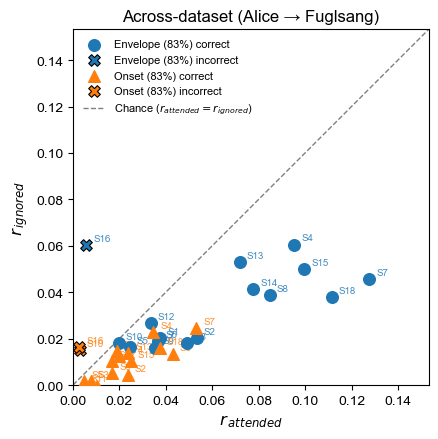

In [7]:
# ─────────────────────────────────────────────
# Run classifier — across dataset (Alice → Fuglsang)
# ─────────────────────────────────────────────

decisions_env   = {}
decisions_onset = {}
r_atts_env      = {}
r_igns_env      = {}
r_atts_onset    = {}
r_igns_onset    = {}

# Load Alice universal TRFs once
trf_env = eelbrain.load.unpickle(
    ALICE_TRF_DIR / f'64hz-universal-{helper_functions.get_trf_model_name(DATASET_TYPE.ALICE, PREDICTOR_TYPE.ENVELOPE, ATTENTION_TYPE.SINGLE, MODEL_TYPE.BACKWARD)}.pickle'
)
trf_onset = eelbrain.load.unpickle(
    ALICE_TRF_DIR / f'64hz-universal-{helper_functions.get_trf_model_name(DATASET_TYPE.ALICE, PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.SINGLE, MODEL_TYPE.BACKWARD)}.pickle'
)

for subject in FUGLSANG_SUBJECTS:
    eeg = eelbrain.load.unpickle(
        FUGLSANG_EEG_DIR / subject / f'{subject} eeg_trimmed.pickle'
    )
    true_att_env = eelbrain.load.unpickle(
        FUGLSANG_PRED_CONCAT_SELF_DIR / subject / f'attended_envelope_concat.pickle'
    ).x
    true_ign_env = eelbrain.load.unpickle(
        FUGLSANG_PRED_CONCAT_SELF_DIR / subject / f'ignored_envelope_concat.pickle'
    ).x
    true_att_onset = eelbrain.load.unpickle(
        FUGLSANG_PRED_CONCAT_SELF_DIR / subject / f'attended_envelope_onset_concat.pickle'
    ).x
    true_ign_onset = eelbrain.load.unpickle(
        FUGLSANG_PRED_CONCAT_SELF_DIR / subject / f'ignored_envelope_onset_concat.pickle'
    ).x

    dec_env,   r_att_env,   r_ign_env   = helper_functions.aad_single_classifier(eeg, true_att_env,   true_ign_env,   trf_env)
    dec_onset, r_att_onset, r_ign_onset = helper_functions.aad_single_classifier(eeg, true_att_onset, true_ign_onset, trf_onset)

    decisions_env[subject]   = dec_env
    decisions_onset[subject] = dec_onset
    r_atts_env[subject]      = r_att_env
    r_igns_env[subject]      = r_ign_env
    r_atts_onset[subject]    = r_att_onset
    r_igns_onset[subject]    = r_ign_onset

    print(f"{subject}: env r_att={r_att_env:.3f}, r_ign={r_ign_env:.3f} | onset r_att={r_att_onset:.3f}, r_ign={r_ign_onset:.3f}")

acc_env   = sum(decisions_env.values())   / len(FUGLSANG_SUBJECTS)
acc_onset = sum(decisions_onset.values()) / len(FUGLSANG_SUBJECTS)
print(f"\n✅ Envelope classification: {acc_env:.2%}")
print(f"✅ Onset classification:    {acc_onset:.2%}")

# ─────────────────────────────────────────────
# Plot
# ─────────────────────────────────────────────

helper_functions.set_plot_style()

color_env   = 'tab:blue'
color_onset = 'tab:orange'
subjects    = list(r_atts_env.keys())

env_att   = [r_atts_env[s]   for s in subjects]
env_ign   = [r_igns_env[s]   for s in subjects]
onset_att = [r_atts_onset[s] for s in subjects]
onset_ign = [r_igns_onset[s] for s in subjects]

fig, ax = plt.subplots(figsize=(4.5, 4.5))

# Correct = circle, incorrect = X
for r_att, r_ign, decisions, color, marker, label in [
    (env_att,   env_ign,   decisions_env,   color_env,   'o', f'Envelope ({acc_env:.0%})'),
    (onset_att, onset_ign, decisions_onset, color_onset, '^', f'Onset ({acc_onset:.0%})'),
]:
    correct   = np.array([decisions[s] for s in subjects])
    incorrect = ~correct

    ax.scatter(np.array(r_att)[correct],   np.array(r_ign)[correct],
               color=color, marker=marker, s=70, zorder=4,
               label=f'{label} correct')
    ax.scatter(np.array(r_att)[incorrect], np.array(r_ign)[incorrect],
               color=color, marker='X', s=70, zorder=4,
               edgecolors='black', linewidths=0.8,
               label=f'{label} incorrect')

for s, xi, yi in zip(subjects, env_att, env_ign):
    ax.annotate(s, (xi, yi), textcoords='offset points',
                xytext=(5, 3), fontsize=7, color=color_env, alpha=0.85)
for s, xi, yi in zip(subjects, onset_att, onset_ign):
    ax.annotate(s, (xi, yi), textcoords='offset points',
                xytext=(5, 3), fontsize=7, color=color_onset, alpha=0.85)

all_vals = env_att + env_ign + onset_att + onset_ign
lim = max(all_vals) * 1.2
ax.plot([0, lim], [0, lim], color='gray', linestyle='--', linewidth=1,
        label=r'Chance ($r_{attended} = r_{ignored}$)', zorder=2)

ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel(r'$r_{\,attended}$', fontsize=12)
ax.set_ylabel(r'$r_{\,ignored}$', fontsize=12)
ax.set_title('Across-dataset (Alice → Fuglsang)', fontsize=12)
ax.legend(frameon=False, fontsize=8, loc='upper left')
ax.set_aspect('equal')

fig.tight_layout()
#fig.savefig(BEYOND_FIGURES_DIR / 'across-dataset-scatter.png', dpi=150, bbox_inches='tight')
plt.show()

Attended means: [np.float64(0.05139811861551166), np.float64(0.018419682504086977)]
Ignored means: [np.float64(0.028537302502101354), np.float64(0.00977442806381617)]

Attended SDs: [np.float64(0.041538065671521254), np.float64(0.01599959903969324)]
Ignored SDs: [np.float64(0.021864996766483385), np.float64(0.00805909068844721)]


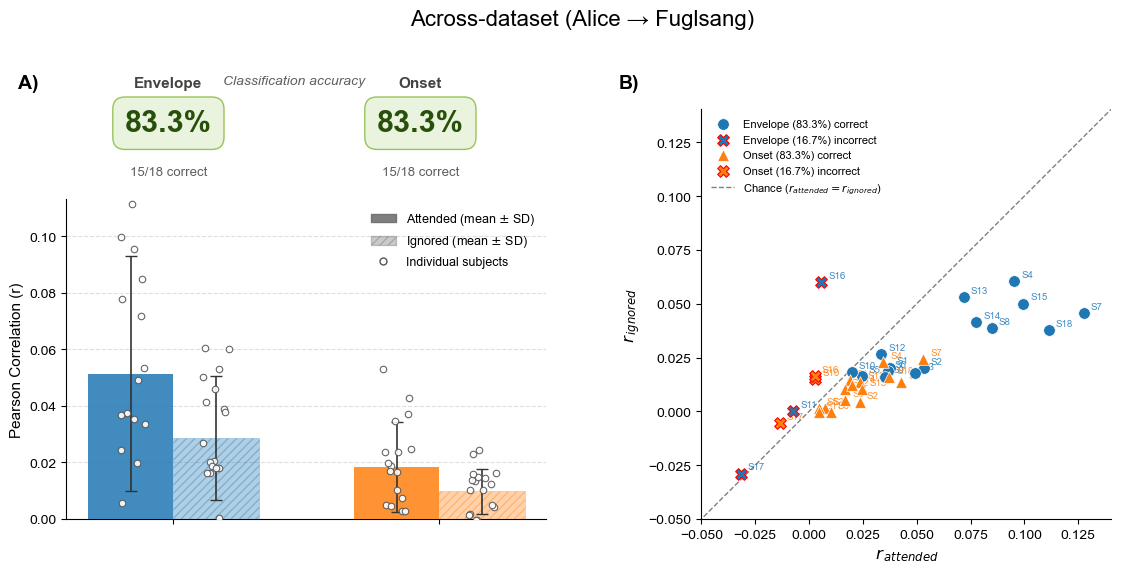

In [8]:
# ─────────────────────────────────────────────
# Prepare data
# ─────────────────────────────────────────────

subjects = list(r_atts_env.keys())

att_vals_all = [np.array(list(r_atts_env.values())),   np.array(list(r_atts_onset.values()))]
ign_vals_all = [np.array(list(r_igns_env.values())),   np.array(list(r_igns_onset.values()))]
att_means    = [v.mean() for v in att_vals_all]
ign_means    = [v.mean() for v in ign_vals_all]
att_sds      = [v.std()  for v in att_vals_all]
ign_sds      = [v.std()  for v in ign_vals_all]

print("Attended means:", att_means)
print("Ignored means:", ign_means)

print("\nAttended SDs:", att_sds)
print("Ignored SDs:", ign_sds)

correct_env   = sum(decisions_env.values())
correct_onset = sum(decisions_onset.values())
total         = len(subjects)

predictor_labels = ['Envelope', 'Onset']
colors_pred      = ['tab:blue', 'tab:orange']
x                = np.arange(len(predictor_labels))
width            = 0.32

env_att   = [r_atts_env[s]   for s in subjects]
env_ign   = [r_igns_env[s]   for s in subjects]
onset_att = [r_atts_onset[s] for s in subjects]
onset_ign = [r_igns_onset[s] for s in subjects]

# ─────────────────────────────────────────────
# Figure layout
# ─────────────────────────────────────────────

helper_functions.set_plot_style()

fig = plt.figure(figsize=(12, 5))

# Left half: bar plot (with badge area on top)
ax_top_l = fig.add_axes([0.05, 0.75, 0.42, 0.22])
ax_bar   = fig.add_axes([0.07, 0.08, 0.40, 0.64])

# Right half: scatter
ax_scat  = fig.add_axes([0.57, 0.08, 0.40, 0.82])

# ── Accuracy badges (left) ────────────────────────────────────────────────────
ax_top_l.axis('off')
ax_top_l.set_xlim(0, 1)
ax_top_l.set_ylim(0, 1)

ax_top_l.text(0.5, 1.0, 'Classification accuracy',
              ha='center', va='top', fontsize=10,
              color='#5F5E5A', fontstyle='italic',
              transform=ax_top_l.transAxes)

for i, (pred, correct) in enumerate(zip(predictor_labels, [correct_env, correct_onset])):
    pct  = correct / total * 100
    xpos = 0.25 + i * 0.5

    ax_top_l.text(xpos, 0.98, pred,
                  ha='center', va='top', fontsize=11,
                  color='#444441', fontweight='bold')
    ax_top_l.text(xpos, 0.68, f'{pct:.1f}%',
                  ha='center', va='top', fontsize=22, fontweight='bold',
                  color='#27500A',
                  bbox=dict(boxstyle='round,pad=0.4', facecolor='#EAF3DE',
                            edgecolor='#97C459', linewidth=1))
    ax_top_l.text(xpos, 0.05, f'{correct}/{total} correct',
                  ha='center', va='bottom', fontsize=9.5,
                  color='#5F5E5A')

# ── Bar + dot plot (left) ─────────────────────────────────────────────────────
for i, (col, att_m, att_s, ign_m, ign_s) in enumerate(
        zip(colors_pred, att_means, att_sds, ign_means, ign_sds)):

    ax_bar.bar(i - width/2, att_m, width, color=col, alpha=0.85,
               yerr=att_s, capsize=4,
               error_kw={'ecolor': '#333', 'linewidth': 1.2},
               zorder=3)
    ax_bar.bar(i + width/2, ign_m, width, color=col, alpha=0.35,
               yerr=ign_s, capsize=4,
               error_kw={'ecolor': '#333', 'linewidth': 1.2},
               zorder=3, hatch='////', edgecolor=col, linewidth=0.5)

np.random.seed(42)
for i, (att_vals, ign_vals) in enumerate(zip(att_vals_all, ign_vals_all)):
    jitter = 0.055
    xa = np.random.uniform(i - width/2 - jitter, i - width/2 + jitter, len(att_vals))
    xi = np.random.uniform(i + width/2 - jitter, i + width/2 + jitter, len(ign_vals))
    ax_bar.scatter(xa, att_vals, color='white', edgecolors='#555',
                   s=22, linewidths=0.8, zorder=4, alpha=0.9)
    ax_bar.scatter(xi, ign_vals, color='white', edgecolors='#555',
                   s=22, linewidths=0.8, zorder=4, alpha=0.9)

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(['', ''])
ax_bar.set_ylabel('Pearson Correlation (r)', fontsize=11)
ax_bar.set_ylim(0, max(max(att_means), max(ign_means)) * 2.2)
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)
ax_bar.yaxis.grid(True, linestyle='--', alpha=0.4)
ax_bar.set_axisbelow(True)

att_patch = mpatches.Patch(color='dimgray', alpha=0.85, label=r'Attended (mean $\pm$ SD)')
ign_patch = mpatches.Patch(color='dimgray', alpha=0.35, hatch='////',
                            label=r'Ignored (mean $\pm$ SD)')
dot_patch = mlines.Line2D([], [], marker='o', color='w', markeredgecolor='#555',
                           markersize=5, label='Individual subjects', linewidth=0)
ax_bar.legend(handles=[att_patch, ign_patch, dot_patch],
              frameon=False, fontsize=9, loc='upper right')

# ── Scatter (right) ───────────────────────────────────────────────────────────
color_env   = 'tab:blue'
color_onset = 'tab:orange'

for r_att, r_ign, decisions, color, marker, label, acc in [
    (env_att,   env_ign,   decisions_env,   color_env,   'o', 'Envelope', correct_env/total),
    (onset_att, onset_ign, decisions_onset, color_onset, '^', 'Onset',    correct_onset/total),
]:
    r_att_arr = np.array(r_att)
    r_ign_arr = np.array(r_ign)
    correct   = np.array([decisions[s] for s in subjects])
    incorrect = ~correct

    ax_scat.scatter(r_att_arr[correct], r_ign_arr[correct],
                    color=color, marker=marker, s=70, zorder=4,
                    edgecolors='white', linewidths=0.5,
                    label=f'{label} ({acc:.1%}) correct')
    ax_scat.scatter(r_att_arr[incorrect], r_ign_arr[incorrect],
                    color=color, marker='X', s=70, zorder=4,
                    edgecolors='red', linewidths=0.8,
                    label=f'{label} ({1-acc:.1%}) incorrect')

    for s, xi, yi in zip(subjects, r_att, r_ign):
        ax_scat.annotate(s, (xi, yi), textcoords='offset points',
                         xytext=(5, 3), fontsize=7, color=color, alpha=0.85)

all_vals = env_att + env_ign + onset_att + onset_ign
lim = max(all_vals) * 1.1
ax_scat.plot([-0.1, lim], [-0.1, lim], color='gray', linestyle='--', linewidth=1,
             label=r'Chance ($r_{attended} = r_{ignored}$)', zorder=2)
ax_scat.set_xlim(-0.05, lim)
ax_scat.set_ylim(-0.05, lim)
ax_scat.set_xlabel(r'$r_{\,attended}$', fontsize=12)
ax_scat.set_ylabel(r'$r_{\,ignored}$', fontsize=12)
ax_scat.set_aspect('equal')
ax_scat.legend(frameon=False, fontsize=8, loc='upper left')
ax_scat.spines['top'].set_visible(False)
ax_scat.spines['right'].set_visible(False)

# ── Panel labels ──────────────────────────────────────────────────────────────
fig.text(0.03, 0.97, 'A)', fontsize=14, fontweight='bold', va='top')
fig.text(0.53, 0.97, 'B)', fontsize=14, fontweight='bold', va='top')

fig.suptitle('Across-dataset (Alice → Fuglsang)', y=1.1)
fig.savefig(BEYOND_FIGURES_DIR / 'beyond_alice_in_fuglsang_results.png', dpi=200, bbox_inches='tight')
plt.show()